## Part 2: Transformation + exploratory analysis (Rangeetha)
Vehicle 531 · VED · polynomial case

Inspect the shared cleaned data, plot raw fuel use against speed, discuss the visible pattern, and create speed_sq = speed**2.
The proposed model is
$$\mathrm{fuel\_use} = w_2\,\mathrm{speed}^2 + w_1\,\mathrm{speed} + b.$$

This notebook runs main.ipynb to generate analysis_df and speed_df, then copies those DataFrames for the plots and polynomial transformation. 


In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


MAIN_NOTEBOOK = Path('main.ipynb').resolve()
if not MAIN_NOTEBOOK.is_file():
    raise FileNotFoundError(f'Cannot find {MAIN_NOTEBOOK}. Set MAIN_NOTEBOOK to its location.')
PROJECT_ROOT = next((p for p in [MAIN_NOTEBOOK.parent, *MAIN_NOTEBOOK.parent.parents]
                     if (p / 'data' / 'ved_vehicle531.csv').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Expected data/ved_vehicle531.csv under the project root.')
# The supplied main imports `from data_loader import DataLoader`.
for folder in [MAIN_NOTEBOOK.parent, PROJECT_ROOT / 'src']:
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))
from transform_analysis import PolynomialTransformer, VehicleEDA

FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)


In [2]:
# Equivalent to `%run ./main.ipynb`, with an explicit path and working directory.

globals().pop('analysis_df', None)
globals().pop('speed_df', None)
_previous_directory = Path.cwd()
try:
    os.chdir(PROJECT_ROOT)
    get_ipython().run_line_magic('run', f'"{MAIN_NOTEBOOK}"')
finally:
    os.chdir(_previous_directory)

if not isinstance(globals().get('analysis_df'), pd.DataFrame):
    raise RuntimeError('main.ipynb did not produce analysis_df as a DataFrame.')
if not isinstance(globals().get('speed_df'), pd.DataFrame):
    raise RuntimeError('main.ipynb did not produce speed_df as a DataFrame.')
analysis_df = analysis_df.copy(deep=True)
speed_df = speed_df.copy(deep=True)

# Validate the handoff without changing rows, values, or their order.
required_raw = ['Trip', 'Timestamp(ms)', 'Vehicle Speed[km/h]',
                'MAF[g/sec]', 'Fuel Rate[L/hr]', 'Fuel Use[L/100km]']
required_speed = ['speed', 'fuel_use', 'n_readings']
for frame, columns, label in [(analysis_df, required_raw, 'raw readings'),
                               (speed_df, required_speed, 'speed averages')]:
    missing = set(columns) - set(frame.columns)
    if missing:
        raise ValueError(f'{label}: missing columns {sorted(missing)}')
    if not np.isfinite(frame[columns].to_numpy(dtype=float)).all():
        raise ValueError(f'{label}: unexpected missing or non-finite values')
assert len(analysis_df) == 308021, 'Prepared dataset changed: review the handoff.'
assert len(speed_df) == 76, 'Prepared speed groups changed: review the handoff.'
assert analysis_df['Vehicle Speed[km/h]'].ge(10).all()
assert speed_df['speed'].between(10, 85).all()
assert speed_df['speed'].is_unique and speed_df['n_readings'].ge(100).all()
display(pd.DataFrame({'dataset': ['Raw retained readings', 'Speed averages'],
                      'rows': [len(analysis_df), len(speed_df)]}))
display(speed_df.head())


Rows: 381,876
Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 381876 entries, 0 to 381875
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   DayNum               381876 non-null  float64
 1   VehId                381876 non-null  int64  
 2   Trip                 381876 non-null  int64  
 3   Timestamp(ms)        381876 non-null  int64  
 4   Vehicle Speed[km/h]  381876 non-null  float64
 5   MAF[g/sec]           381876 non-null  float64
dtypes: float64(3), int64(3)
memory usage: 17.5 MB
Missing values per column:
DayNum                 0
VehId                  0
Trip                   0
Timestamp(ms)          0
Vehicle Speed[km/h]    0
MAF[g/sec]             0
dtype: int64

Duplicate rows: 0
Duplicate (Trip, Timestamp) readings: 0
Idling readings (speed = 0): 44,092
Rows remaining: 337,784
Removed below 10 km/h: 29,763
Rows remaining: 308,021
Speed points: 76 (10 to 85 km/h)
Fewest readings behin

,dataset,rows
0,Raw retained readings,308021
1,Speed averages,76


,speed,fuel_use,n_readings
0,10.0,19.684143,2516
1,11.0,17.663447,2696
2,12.0,18.417285,2811
3,13.0,16.782284,2949
4,14.0,15.566125,3152



This section uses the preparation agreed in main notebook. analysis_df contains the raw observations retained at speed ≥ 10 km/h; speed_df contains one average for each rounded-speed group with at least 100 readings. 
The response here is estimated fuel use derived from MAF, not directly measured fuel rate. We retain the preparation's assumptions: air/fuel mass ratio 14.7 and gasoline density 745 g/L. 

#### Look first: raw fuel use vs speed
Each point is one retained observation. This is an unaggregated scatter after the group's speed filter, with all 308,021 retained readings and no sampling or additional trimming. Transparency exposes overlap. The axes remain in original units; the plot is not a fitted curve.

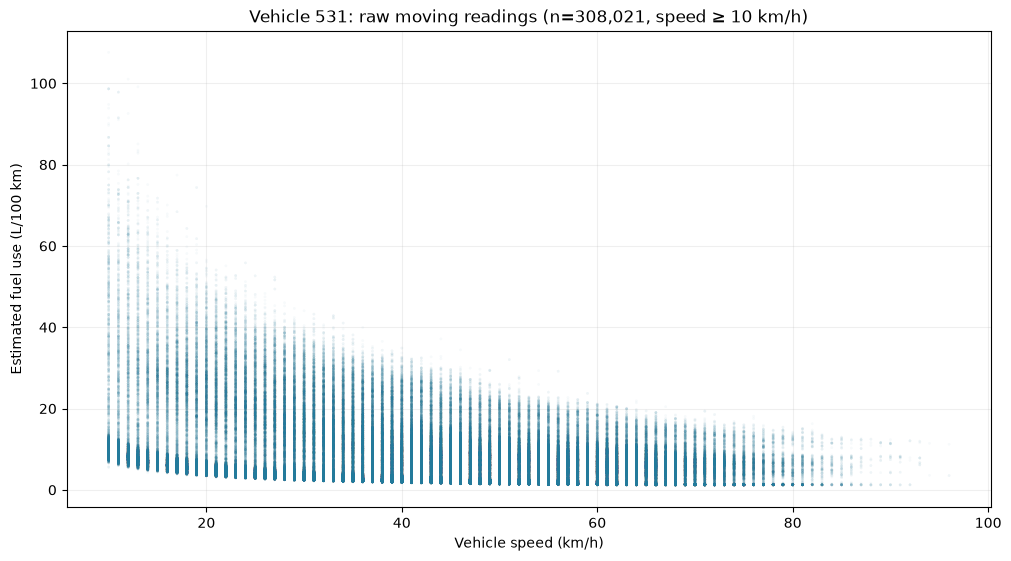

In [3]:
eda = VehicleEDA()
fig, ax = eda.raw_scatter(analysis_df)
fig.savefig(FIGURE_DIR / 'vehicle531_raw_scatter.png', dpi=160, bbox_inches='tight')
plt.show()


#### Inspect the data that will be modelled
Raw observations have considerable variation at the same speed. The following scatter shows the 76 prepared speed-level averages, with colour indicating the number of source readings behind each point. It is a descriptive plot, with no fitted line or curve. Averaging reduces visible variability but does not eliminate effects of driving conditions or establish a causal effect of speed.

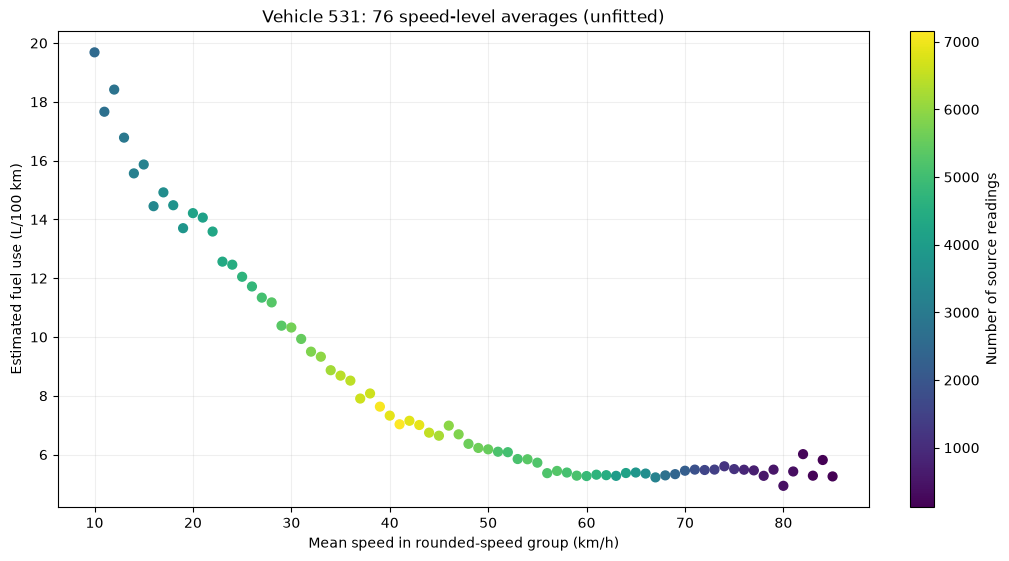

,speed,fuel_use,n_readings
0,10.0,19.684,2516
75,85.0,5.257,117


Lowest observed group average: 4.937 L/100 km at 80 km/h
Raw observations: 308,021; modelling rows: 76


In [4]:
fig, ax = eda.speed_scatter(speed_df)
fig.savefig(FIGURE_DIR / 'vehicle531_speed_averages.png', dpi=160, bbox_inches='tight')
plt.show()
lowest = speed_df.loc[speed_df['fuel_use'].idxmin()]
display(speed_df.iloc[[0, -1]].round(3))
print(f"Lowest observed group average: {lowest['fuel_use']:.3f} L/100 km at {lowest['speed']:.0f} km/h")
print(f"Raw observations: {len(analysis_df):,}; modelling rows: {len(speed_df)}")


##### Explain the curvature
The prepared averages fall from about 19.684 L/100 km at 10 km/h to 4.937 L/100 km at 80 km/h, then reach 5.257 L/100 km at 85 km/h. The rate of decrease is not constant: the visible trend motivates a curved candidate rather than assuming a constant slope. The small upturn at the upper end is descriptive; fewer readings support those speeds, so it is not proof of a general optimum.
The target definition helps explain the shape:
$$\mathrm{fuel\_use}=100\,\frac{\mathrm{fuel\_rate}}{\mathrm{speed}}.$$
For a fixed positive fuel rate, this is an inverse curve. For example, 2 L/hr corresponds to 20 L/100 km at 10 km/h and 4 L/100 km at 50 km/h. Actual fuel rate varies too. Since speed is also in the denominator of the target, the association is partly mathematical coupling; this scatter alone cannot identify speed's causal effect.
A quadratic allows changing slope and is the lab's proposed approximation over the observed modelling range of 10–85 km/h. Neither these plots nor the transformation proves that it outperforms a straight line. That question belongs to the later R², RMSE, and residual checks. Results on speed-level averages describe aggregated data and should not be presented as accuracy on individual driving observations.
Preparation limits: MAF-based fuel rate is an estimate under the stated constant-ratio assumptions. The minimum-speed filter changes the study population, and the minimum-count rule removes sparse speed groups. Averaging does not guarantee steady-speed driving or cancel all confounding effects. Each speed average weights every reading equally rather than by elapsed time, so it is not an exact total-fuel/total-distance figure. Part 1 checks that time-weighting gives almost the same curve.

### Create the polynomial feature
Use the shared variable names speed, speed_sq, and fuel_use:

$$\mathrm{fuel\_use}=w_2\,\mathrm{speed\_sq}+w_1\,\mathrm{speed}+b.$$

This expands one predictor into two known features. For example, speed 10 becomes `(10, 100)`, and speed 20 becomes `(20, 400)`. Squared speed has units `(km/h)²`.

The relationship is nonlinear in speed but **linear in the unknown weights**: the weights are neither squared nor multiplied together. The slope `2*w2*speed + w1` can vary with speed, so least squares can represent a bend. The target is unchanged, and no inverse target transformation is required.

In [5]:
before_transform = speed_df.copy(deep=True)
speed_df = PolynomialTransformer().transform(speed_df)
speed = speed_df['speed'].to_numpy()
speed_sq = speed_df['speed_sq'].to_numpy()
fuel_use = speed_df['fuel_use'].to_numpy()

np.testing.assert_array_equal(speed_sq, speed ** 2)
pd.testing.assert_frame_equal(speed_df[before_transform.columns], before_transform)
assert len(speed_df) == 76
assert np.isfinite(speed_df[['speed', 'speed_sq', 'fuel_use']].to_numpy()).all()
display(speed_df[['speed', 'speed_sq', 'fuel_use', 'n_readings']].head(10))
print('Verified: row order, target, counts, and original speed values are unchanged.')


,speed,speed_sq,fuel_use,n_readings
0,10.0,100.0,19.684143,2516
1,11.0,121.0,17.663447,2696
2,12.0,144.0,18.417285,2811
3,13.0,169.0,16.782284,2949
4,14.0,196.0,15.566125,3152
5,15.0,225.0,15.868439,3205
6,16.0,256.0,14.450312,3378
7,17.0,289.0,14.920329,3540
8,18.0,324.0,14.482670,3732
9,19.0,361.0,13.701966,3802


Verified: row order, target, counts, and original speed values are unchanged.


##### Note to Modelling Team 
NumPy: columns [speed_sq, speed, 1] correspond to [w2, w1, b].
scikit-learn: PolynomialFeatures(degree=2, include_bias=False) applied to speed gives [speed, speed_sq]; use w1, w2 = model.coef_ and b = model.intercept_ when the regressor fits an intercept.
Both implementations must use these same 76 rows and the same weighting and any later split. n_readings is descriptive metadata, not an additional predictor. Matching ordinary least squares means each speed-group row has equal weight unless both teams explicitly agree otherwise. The following cell prepares arrays only; it does not fit a model.

In [6]:
X_numpy = np.column_stack([speed_sq, speed, np.ones_like(speed)])
X_sklearn_order = np.column_stack([speed, speed_sq])
x = speed  # Compatibility with the group's existing handoff.
y = fuel_use
assert X_numpy.shape == (76, 3)
assert X_sklearn_order.shape == (76, 2)
FEATURE_PATH = PROJECT_ROOT / 'data' / 'vehicle531_speed_features.csv'
speed_df.to_csv(FEATURE_PATH, index=False)
print('Saved:', FEATURE_PATH.name)
print('NumPy columns: [speed_sq, speed, 1] -> [w2, w1, b]')
print('sklearn columns: [speed, speed_sq] -> [w1, w2], with separate intercept')


Saved: vehicle531_speed_features.csv
NumPy columns: [speed_sq, speed, 1] -> [w2, w1, b]
sklearn columns: [speed, speed_sq] -> [w1, w2], with separate intercept


##### Summary 

Plotted the retained raw readings and the prepared speed averages, explained why curvature is plausible and what the plots cannot establish, and created speed_sq while preserving the shared modelling rows and target. 